# Context
## A response model can provide a significant boost to the efficiency of a marketing campaign by increasing responses or reducing expenses. The objective is to predict who will respond to an offer for a product or service

# Inspiration
## The main objective is to train a predictive model which allows the company to maximize the profit of the next marketing campaign.

### Pipeline : Cleaning Raw Data -> Encoding -> Train/Test split -> Model training -> Predictor (probability assignment) -> Taking desicion

In [35]:
# import libraries
import sys 
import numpy as np
import pandas as pd 
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Get the data

In [36]:
marketing_campaign_data_path = os.path.join("datasets", "marketing_campaign")
def get_data(path_data = marketing_campaign_data_path):
    csv_file = os.path.join(path_data, "marketing_campaign.csv")
    return pd.read_csv(csv_file, sep=";")

df_marketing = get_data()
df_marketing.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Understanding 

In [37]:
# Overall information data type 
df_marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [38]:
# Missing data 
print("missing data")
df_marketing.isnull().sum()

missing data


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [39]:
# Duplicated values
print("duplicated values")
df_marketing.duplicated().sum()

duplicated values


0

### Visualize data

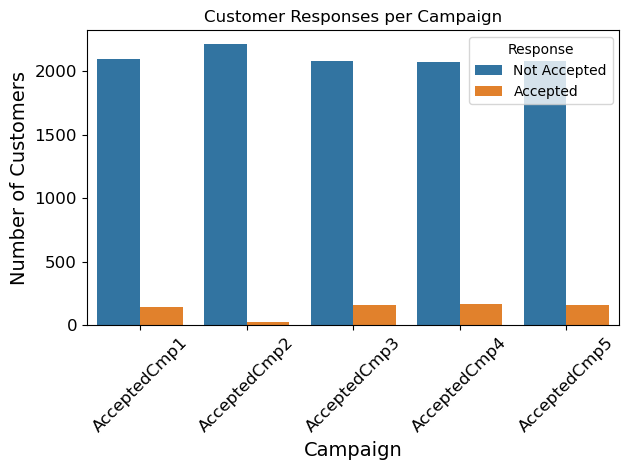

In [40]:
import seaborn as sns
import math

# Campaign behavior 
camp_response_list = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']

df_reshape = df_marketing[camp_response_list].melt(var_name="Campaign", value_name="Accepted")
sns.countplot(data=df_reshape, x="Campaign", hue="Accepted")
plt.legend(title="Response", labels=["Not Accepted", "Accepted"])
plt.ylabel("Number of Customers")
plt.title("Customer Responses per Campaign")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


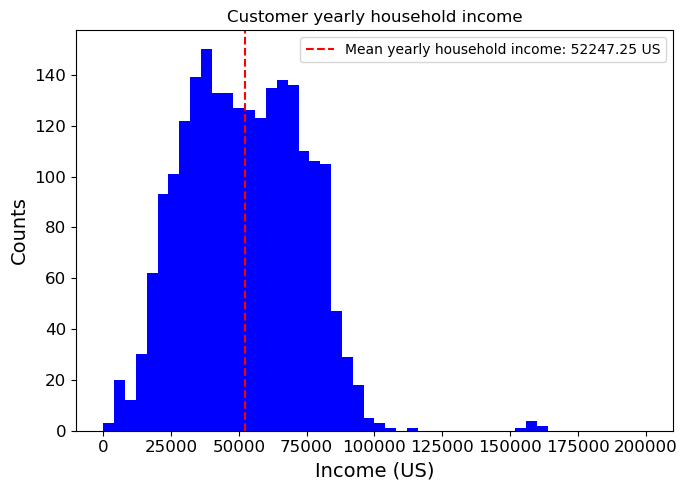

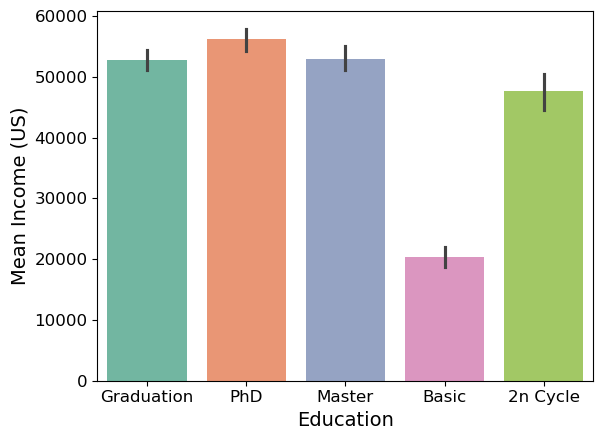

In [75]:
# Personal Customer Information

## Mean income FOR ALL CLASSES
mean_in = df_marketing["Income"].mean()

fig, axs = plt.subplots(figsize=(7,5))
axs.hist(df_marketing["Income"], bins = 50, color = 'b', range = (0,200000))
axs.axvline(x=mean_in, color = 'r', linestyle = '--', label = f'Mean yearly household income: {mean_in:.2f} US')
plt.xlabel("Income (US)")
plt.ylabel("Counts")
plt.title("Customer yearly household income")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

## Mean income per education level

fig, ax = plt.subplots()
sns.barplot(data=df_marketing, x="Education", y="Income", hue="Education", palette="Set2")
plt.ylabel("Mean Income (US)")
plt.show()
plt.close()
